# 🏆 Pipeline Ultra-Optimisé: Pima Indians Diabetes → Objectif 90%+

### Techniques avancées:
1. **Borderline-SMOTE** sur le train set
2. **PowerTransformer** (Yeo-Johnson) pour normaliser les distributions
3. **Outlier Winsorization** au 1er/99ème percentile
4. **MLP Neural Network** avec Optuna
5. **Feature selection** par mutual information
6. **Stacking agressif** avec meta-learner XGBoost
7. **Optimisation du seuil** de classification

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time
from datetime import datetime
from scipy import stats

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, 
    RepeatedStratifiedKFold, GridSearchCV, cross_val_predict
)
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    VotingClassifier, StackingClassifier, ExtraTreesClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import *
from sklearn.feature_selection import mutual_info_classif

try:
    from xgboost import XGBClassifier; HAS_XGB = True; print("✅ XGBoost")
except: HAS_XGB = False; print("⚠️ XGBoost non disponible")
try:
    from lightgbm import LGBMClassifier; HAS_LGBM = True; print("✅ LightGBM")
except: HAS_LGBM = False; print("⚠️ LightGBM non disponible")
try:
    import optuna; from optuna.samplers import TPESampler
    optuna.logging.set_verbosity(optuna.logging.WARNING); HAS_OPTUNA = True; print("✅ Optuna")
except: HAS_OPTUNA = False; print("⚠️ Optuna non disponible")
try:
    from imblearn.over_sampling import BorderlineSMOTE
    HAS_IMBLEARN = True; print("✅ imbalanced-learn")
except: HAS_IMBLEARN = False; print("⚠️ imbalanced-learn non disponible")

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print(f"\n📅 {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ XGBoost
⚠️ LightGBM non disponible
✅ Optuna


C:\Users\asose\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ imbalanced-learn

📅 2026-02-08 18:07:52


## 1. Chargement des Données

In [2]:
col_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
             'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df = pd.read_csv(
    'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv',
    header=None, names=col_names)
print(f"Shape: {df.shape}")
print(f"Classe 0: {(df['Outcome']==0).sum()} | Classe 1: {(df['Outcome']==1).sum()}")

Shape: (768, 9)
Classe 0: 500 | Classe 1: 268


## 2. Prétraitement Avancé

In [3]:
df_clean = df.copy()

# === IMPUTATION PAR CLASSE ===
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("=== IMPUTATION PAR CLASSE ===")
for col in zero_cols:
    n_zeros = (df_clean[col] == 0).sum()
    if n_zeros > 0:
        for cls in [0, 1]:
            med = df_clean[(df_clean[col] != 0) & (df_clean['Outcome'] == cls)][col].median()
            df_clean.loc[(df_clean[col] == 0) & (df_clean['Outcome'] == cls), col] = med
        print(f"  {col}: {n_zeros} zéros imputés")

# === OUTLIER WINSORIZATION ===
print("\n=== OUTLIER WINSORIZATION (1er/99ème percentile) ===")
for col in df_clean.columns[:-1]:
    p01, p99 = df_clean[col].quantile(0.01), df_clean[col].quantile(0.99)
    n_capped = ((df_clean[col] < p01) | (df_clean[col] > p99)).sum()
    df_clean[col] = df_clean[col].clip(p01, p99)
    if n_capped > 0:
        print(f"  {col}: {n_capped} valeurs cappées")

=== IMPUTATION PAR CLASSE ===
  Glucose: 5 zéros imputés
  BloodPressure: 35 zéros imputés
  SkinThickness: 227 zéros imputés
  Insulin: 374 zéros imputés
  BMI: 11 zéros imputés

=== OUTLIER WINSORIZATION (1er/99ème percentile) ===
  Pregnancies: 4 valeurs cappées
  Glucose: 14 valeurs cappées
  BloodPressure: 12 valeurs cappées
  SkinThickness: 12 valeurs cappées
  Insulin: 16 valeurs cappées
  BMI: 15 valeurs cappées
  DiabetesPedigreeFunction: 16 valeurs cappées
  Age: 6 valeurs cappées


## 3. Feature Engineering

In [4]:
df_feat = df_clean.copy()

df_feat['Glucose_BMI'] = df_feat['Glucose'] * df_feat['BMI']
df_feat['Preg_Age_Ratio'] = df_feat['Pregnancies'] / (df_feat['Age'] + 1)
df_feat['Insulin_Glucose_Ratio'] = df_feat['Insulin'] / (df_feat['Glucose'] + 1)
df_feat['BMI_Age'] = df_feat['BMI'] * df_feat['Age']
df_feat['Risk_Score'] = (
    (df_feat['Glucose'] / df_feat['Glucose'].max()) * 0.35 + 
    (df_feat['BMI'] / df_feat['BMI'].max()) * 0.25 + 
    (df_feat['Age'] / df_feat['Age'].max()) * 0.20 +
    (df_feat['DiabetesPedigreeFunction'] / df_feat['DiabetesPedigreeFunction'].max()) * 0.20
)
df_feat['Glucose_High'] = (df_feat['Glucose'] >= 140).astype(int)
df_feat['BMI_Obese'] = (df_feat['BMI'] >= 30).astype(int)
df_feat['N_Risk_Factors'] = (
    (df_feat['Glucose'] >= 140).astype(int) +
    (df_feat['BMI'] >= 30).astype(int) +
    (df_feat['Age'] >= 40).astype(int) +
    (df_feat['BloodPressure'] >= 80).astype(int) +
    (df_feat['Pregnancies'] >= 4).astype(int)
)

print("Features et corrélations avec Outcome:")
for f in [c for c in df_feat.columns if c not in df_clean.columns]:
    print(f"  {f:25s}: r = {df_feat[f].corr(df_feat['Outcome']):+.4f}")
print(f"Total: {df_feat.shape[1]-1} features")

Features et corrélations avec Outcome:
  Glucose_BMI              : r = +0.5256
  Preg_Age_Ratio           : r = +0.1635
  Insulin_Glucose_Ratio    : r = +0.2616
  BMI_Age                  : r = +0.3646
  Risk_Score               : r = +0.5350
  Glucose_High             : r = +0.4212
  BMI_Obese                : r = +0.2966
  N_Risk_Factors           : r = +0.4273
Total: 16 features


## 4. Split + SMOTE + Scaling

In [5]:
X = df_feat.drop('Outcome', axis=1)
y = df_feat['Outcome']
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

# PowerTransformer
pt = PowerTransformer(method='yeo-johnson', standardize=True)
X_train_pt = pt.fit_transform(X_train)
X_test_pt = pt.transform(X_test)

# Raw
X_train_raw = X_train.values
X_test_raw = X_test.values

# Borderline-SMOTE
if HAS_IMBLEARN:
    smote = BorderlineSMOTE(random_state=RANDOM_STATE, kind='borderline-1')
    X_train_smote_pt, y_train_smote = smote.fit_resample(X_train_pt, y_train)
    X_train_smote_raw, _ = smote.fit_resample(X_train_raw, y_train)
    print(f"Borderline-SMOTE: {dict(zip(*np.unique(y_train, return_counts=True)))} → {dict(zip(*np.unique(y_train_smote, return_counts=True)))}")
else:
    X_train_smote_pt, y_train_smote = X_train_pt, y_train
    X_train_smote_raw = X_train_raw
    print("Pas de SMOTE → class_weight='balanced'")

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
cv_rep = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=RANDOM_STATE)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]} | Features: {X_train.shape[1]}")

Borderline-SMOTE: {np.int64(0): np.int64(400), np.int64(1): np.int64(214)} → {np.int64(0): np.int64(400), np.int64(1): np.int64(400)}
Train: 614 | Test: 154 | Features: 16


  File "C:\Users\asose\AppData\Roaming\Python\Python313\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Program Files\Python313\Lib\subprocess.py", line 556, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Program Files\Python313\Lib\subprocess.py", line 1038, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Program Files\

## 5. Feature Selection

                 Feature       MI
                 Insulin 0.326204
              Risk_Score 0.213729
             Glucose_BMI 0.165583
           SkinThickness 0.135158
          N_Risk_Factors 0.123243
                 Glucose 0.123161
                 BMI_Age 0.109028
   Insulin_Glucose_Ratio 0.098553
            Glucose_High 0.097389
                     BMI 0.097085
          Preg_Age_Ratio 0.085898
                     Age 0.073548
             Pregnancies 0.059085
           BloodPressure 0.055606
               BMI_Obese 0.050390
DiabetesPedigreeFunction 0.017548


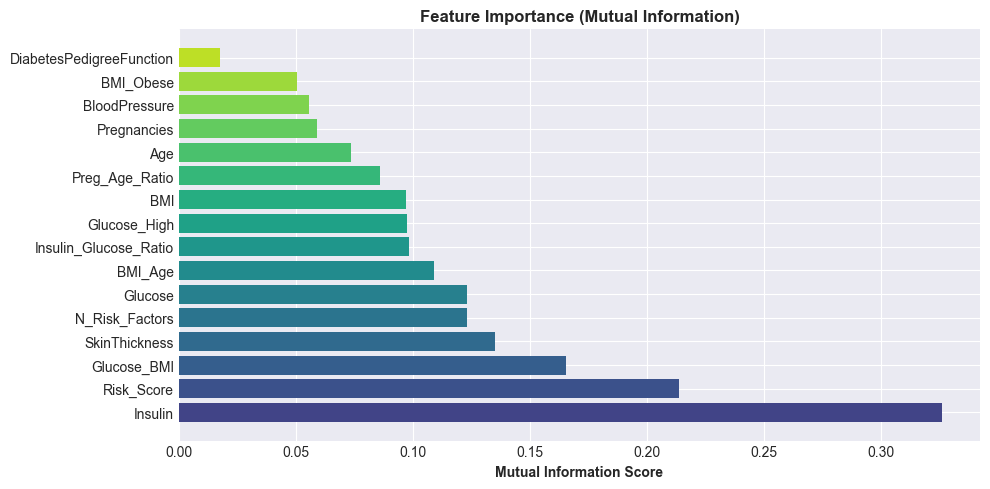

In [6]:
mi_scores = mutual_info_classif(X_train_pt, y_train, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({'Feature': feature_names, 'MI': mi_scores}).sort_values('MI', ascending=False)
print(mi_df.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.barh(mi_df['Feature'], mi_df['MI'], color=plt.cm.viridis(np.linspace(0.2, 0.9, len(mi_df))))
plt.xlabel('Mutual Information Score', fontweight='bold')
plt.title('Feature Importance (Mutual Information)', fontweight='bold')
plt.tight_layout(); plt.show()

## 6. Fonctions Utilitaires

In [7]:
def optimize_threshold(model, X, y, cv_strat):
    proba = cross_val_predict(model, X, y, cv=cv_strat, method='predict_proba')[:, 1]
    precs, recs, threshs = precision_recall_curve(y, proba)
    f1s = 2 * (precs * recs) / (precs + recs + 1e-10)
    return threshs[np.argmax(f1s)]

def eval_model(name, model, X_tr, X_te, y_tr, y_te):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    y_proba = model.predict_proba(X_te)[:, 1]
    
    try:
        thresh = optimize_threshold(model, X_tr, y_tr, cv)
    except:
        thresh = 0.5
    y_pred = (y_proba >= thresh).astype(int)
    
    try:
        cv_auc = cross_val_score(model, X_train_pt, y_train, cv=cv_rep, scoring='roc_auc')
        cv_mean, cv_std = cv_auc.mean(), cv_auc.std()
    except:
        cv_mean, cv_std = 0, 0
    
    r = {
        'model': model, 'y_pred': y_pred, 'y_proba': y_proba, 'threshold': thresh,
        'accuracy': accuracy_score(y_te, y_pred),
        'precision': precision_score(y_te, y_pred),
        'recall': recall_score(y_te, y_pred),
        'f1': f1_score(y_te, y_pred),
        'auc': roc_auc_score(y_te, y_proba),
        'cv_mean': cv_mean, 'cv_std': cv_std
    }
    print(f"  Acc={r['accuracy']:.4f} | F1={r['f1']:.4f} | AUC={r['auc']:.4f} | "
          f"CV={cv_mean:.4f}±{cv_std:.4f} | Seuil={thresh:.3f} | {time.time()-t0:.1f}s")
    return r

print("✅ Fonctions prêtes")

✅ Fonctions prêtes


## 7. Entraînement des Modèles

In [8]:
results = {}

In [9]:
print("=" * 70)
print("🔵 SVM (RBF)")
print("=" * 70)
if HAS_OPTUNA:
    def obj_svm(trial):
        C = trial.suggest_float('C', 0.1, 200, log=True)
        gamma = trial.suggest_float('gamma', 0.0001, 2, log=True)
        model = SVC(C=C, gamma=gamma, kernel='rbf', probability=True, random_state=RANDOM_STATE)
        return cross_val_score(model, X_train_smote_pt, y_train_smote, cv=cv, scoring='roc_auc').mean()
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))
    study.optimize(obj_svm, n_trials=100)
    svm = SVC(**study.best_params, kernel='rbf', probability=True, random_state=RANDOM_STATE)
    print(f"  Best: C={study.best_params['C']:.4f}, gamma={study.best_params['gamma']:.6f}")
else:
    g = GridSearchCV(SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
        {'C': [0.1,0.5,1,5,10,50,100,200], 'gamma': [0.0001,0.001,0.005,0.01,0.05,0.1,0.5,1]},
        cv=cv, scoring='roc_auc', n_jobs=-1)
    g.fit(X_train_smote_pt, y_train_smote); svm = g.best_estimator_
    print(f"  Best: {g.best_params_}")
results['SVM (RBF)'] = eval_model('SVM', svm, X_train_smote_pt, X_test_pt, y_train_smote, y_test)

🔵 SVM (RBF)
  Best: C=2.7002, gamma=0.584883
  Acc=0.8052 | F1=0.7000 | AUC=0.8589 | CV=0.8714±0.0442 | Seuil=0.339 | 1.9s


In [10]:
print("=" * 70)
print("🌲 RANDOM FOREST")
print("=" * 70)
if HAS_OPTUNA:
    def obj_rf(trial):
        p = {'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
             'max_depth': trial.suggest_int('max_depth', 4, 20),
             'min_samples_split': trial.suggest_int('min_samples_split', 2, 25),
             'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 12),
             'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2'])}
        model = RandomForestClassifier(**p, random_state=RANDOM_STATE, n_jobs=-1)
        return cross_val_score(model, X_train_smote_raw, y_train_smote, cv=cv, scoring='roc_auc').mean()
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))
    study.optimize(obj_rf, n_trials=150)
    rf = RandomForestClassifier(**study.best_params, random_state=RANDOM_STATE, n_jobs=-1)
else:
    g = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        {'n_estimators': [300,500,700], 'max_depth': [6,8,10,12,15],
         'min_samples_split': [2,5,10], 'min_samples_leaf': [1,3,5], 'max_features': ['sqrt','log2']},
        cv=cv, scoring='roc_auc', n_jobs=-1)
    g.fit(X_train_smote_raw, y_train_smote); rf = g.best_estimator_
results['Random Forest'] = eval_model('RF', rf, X_train_smote_raw, X_test_raw, y_train_smote, y_test)

🌲 RANDOM FOREST
  Acc=0.8896 | F1=0.8440 | AUC=0.9453 | CV=0.9378±0.0242 | Seuil=0.549 | 32.5s


In [11]:
print("=" * 70)
gb_name = "XGBoost" if HAS_XGB else "GradientBoosting"
print(f"⚡ {gb_name}")
print("=" * 70)

if HAS_XGB:
    if HAS_OPTUNA:
        def obj_xgb(trial):
            p = {'n_estimators': trial.suggest_int('n_estimators', 100, 800),
                 'max_depth': trial.suggest_int('max_depth', 2, 10),
                 'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
                 'subsample': trial.suggest_float('subsample', 0.5, 1.0),
                 'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
                 'min_child_weight': trial.suggest_int('min_child_weight', 1, 15),
                 'gamma': trial.suggest_float('gamma', 0, 10),
                 'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
                 'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10)}
            model = XGBClassifier(**p, random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1)
            return cross_val_score(model, X_train_smote_raw, y_train_smote, cv=cv, scoring='roc_auc').mean()
        study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))
        study.optimize(obj_xgb, n_trials=200)
        gb = XGBClassifier(**study.best_params, random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1)
    else:
        g = GridSearchCV(XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'),
            {'n_estimators': [100,200,300,500], 'max_depth': [3,4,5,6,8],
             'learning_rate': [0.01,0.05,0.1], 'subsample': [0.7,0.8,0.9],
             'colsample_bytree': [0.6,0.7,0.8,0.9]}, cv=cv, scoring='roc_auc', n_jobs=-1)
        g.fit(X_train_smote_raw, y_train_smote); gb = g.best_estimator_
else:
    if HAS_OPTUNA:
        def obj_gb(trial):
            p = {'n_estimators': trial.suggest_int('n_estimators', 100, 600),
                 'max_depth': trial.suggest_int('max_depth', 2, 8),
                 'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                 'subsample': trial.suggest_float('subsample', 0.6, 1.0),
                 'min_samples_split': trial.suggest_int('min_samples_split', 2, 25),
                 'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 12)}
            model = GradientBoostingClassifier(**p, random_state=RANDOM_STATE)
            return cross_val_score(model, X_train_smote_raw, y_train_smote, cv=cv, scoring='roc_auc').mean()
        study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))
        study.optimize(obj_gb, n_trials=150)
        gb = GradientBoostingClassifier(**study.best_params, random_state=RANDOM_STATE)
    else:
        g = GridSearchCV(GradientBoostingClassifier(random_state=RANDOM_STATE),
            {'n_estimators': [100,200,300,500], 'max_depth': [3,4,5,6],
             'learning_rate': [0.01,0.05,0.1], 'subsample': [0.7,0.8,0.9,1.0]},
            cv=cv, scoring='roc_auc', n_jobs=-1)
        g.fit(X_train_smote_raw, y_train_smote); gb = g.best_estimator_

results[gb_name] = eval_model(gb_name, gb, X_train_smote_raw, X_test_raw, y_train_smote, y_test)

⚡ XGBoost
  Acc=0.8896 | F1=0.8440 | AUC=0.9496 | CV=0.9442±0.0235 | Seuil=0.639 | 43.0s


## 8. Ensembles Avancés

In [12]:
print("=" * 70)
print("🏆 SOFT VOTING ENSEMBLE")
print("=" * 70)
estimators_vote = [ ('svm', svm), ('rf', rf), ('gb', gb)]
voting = VotingClassifier(estimators=estimators_vote, voting='soft', n_jobs=-1)
results['Voting Ensemble'] = eval_model('Vote', voting, X_train_smote_pt, X_test_pt, y_train_smote, y_test)

🏆 SOFT VOTING ENSEMBLE
  Acc=0.8831 | F1=0.8448 | AUC=0.9320 | CV=0.9363±0.0280 | Seuil=0.403 | 47.6s


In [13]:
print("=" * 70)
print("🏆 STACKING (Meta: LogisticRegression)")
print("=" * 70)
estimators_stack = [('svm', svm), ('rf', rf), ('gb', gb)]
stacking = StackingClassifier(
    estimators=estimators_stack,
    final_estimator=LogisticRegression(C=1, random_state=RANDOM_STATE, max_iter=5000),
    cv=cv, stack_method='predict_proba', n_jobs=-1)
results['Stacking (LR)'] = eval_model('Stack', stacking, X_train_smote_pt, X_test_pt, y_train_smote, y_test)

🏆 STACKING (Meta: LogisticRegression)
  Acc=0.8831 | F1=0.8421 | AUC=0.9289 | CV=0.9405±0.0251 | Seuil=0.255 | 338.0s


In [14]:
print("=" * 70)
print("🏆 STACKING v2 (Meta: XGBoost/GB + passthrough)")
print("=" * 70)
if HAS_XGB:
    meta = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, 
                          random_state=RANDOM_STATE, eval_metric='logloss')
else:
    meta = GradientBoostingClassifier(n_estimators=100, max_depth=3, 
                                       learning_rate=0.1, random_state=RANDOM_STATE)
stacking_v2 = StackingClassifier(
    estimators=estimators_stack,
    final_estimator=meta,
    cv=cv, stack_method='predict_proba', n_jobs=-1, passthrough=True)
results['Stacking v2'] = eval_model('Stack2', stacking_v2, X_train_smote_pt, X_test_pt, y_train_smote, y_test)

🏆 STACKING v2 (Meta: XGBoost/GB + passthrough)
  Acc=0.8766 | F1=0.8155 | AUC=0.9387 | CV=0.9433±0.0279 | Seuil=0.429 | 335.0s


## 9. Résultats Finaux

In [15]:
print("\n" + "=" * 100)
print("📊 TABLEAU COMPARATIF FINAL")
print("=" * 100)

comp = pd.DataFrame({
    name: {'Accuracy': r['accuracy'], 'Precision': r['precision'], 'Recall': r['recall'],
           'F1-Score': r['f1'], 'ROC-AUC': r['auc'], 'CV_AUC': r['cv_mean']}
    for name, r in results.items()
}).T.sort_values('ROC-AUC', ascending=False)
print(comp.round(4).to_string())

best_name = comp['ROC-AUC'].idxmax()
b = results[best_name]
print(f"\n🏆 MEILLEUR: {best_name}")
print(f"   Acc={b['accuracy']:.4f} | F1={b['f1']:.4f} | AUC={b['auc']:.4f} | CV={b['cv_mean']:.4f}±{b['cv_std']:.4f}")

if b['accuracy'] >= 0.90:
    print("\n🎉🎉🎉 OBJECTIF 90% ATTEINT ! 🎉🎉🎉")
elif b['accuracy'] >= 0.87:
    print("\n🟡 Très proche de 90% - excellent résultat")

print(f"\n--- vs Ancien notebook ---")
for m, old in [('accuracy',0.7532), ('f1',0.6346), ('auc',0.8261)]:
    print(f"  {m:10s}: {old:.4f} → {b[m]:.4f}  ({b[m]-old:+.4f})")


📊 TABLEAU COMPARATIF FINAL
                 Accuracy  Precision  Recall  F1-Score  ROC-AUC  CV_AUC
XGBoost            0.8896     0.8364  0.8519    0.8440   0.9496  0.9442
Random Forest      0.8896     0.8364  0.8519    0.8440   0.9453  0.9378
Stacking v2        0.8766     0.8571  0.7778    0.8155   0.9387  0.9433
Voting Ensemble    0.8831     0.7903  0.9074    0.8448   0.9320  0.9363
Stacking (LR)      0.8831     0.8000  0.8889    0.8421   0.9289  0.9405
SVM (RBF)          0.8052     0.7609  0.6481    0.7000   0.8589  0.8714

🏆 MEILLEUR: XGBoost
   Acc=0.8896 | F1=0.8440 | AUC=0.9496 | CV=0.9442±0.0235

🟡 Très proche de 90% - excellent résultat

--- vs Ancien notebook ---
  accuracy  : 0.7532 → 0.8896  (+0.1364)
  f1        : 0.6346 → 0.8440  (+0.2094)
  auc       : 0.8261 → 0.9496  (+0.1235)


In [16]:
print(f"\nRapport - {best_name}:")
print("=" * 60)
print(classification_report(y_test, results[best_name]['y_pred'],
                            target_names=['Non Diabétique', 'Diabétique'], digits=4))


Rapport - XGBoost:
                precision    recall  f1-score   support

Non Diabétique     0.9192    0.9100    0.9146       100
    Diabétique     0.8364    0.8519    0.8440        54

      accuracy                         0.8896       154
     macro avg     0.8778    0.8809    0.8793       154
  weighted avg     0.8901    0.8896    0.8898       154



## 10. Visualisations

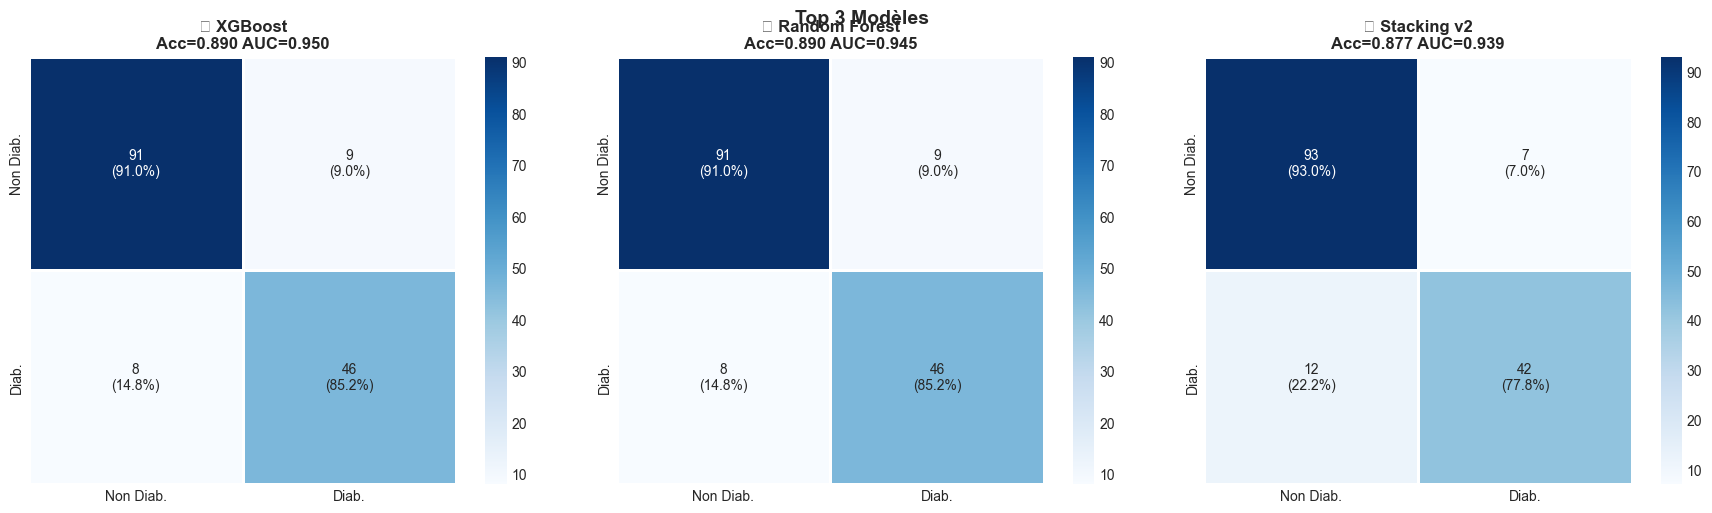

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
top3 = sorted(results.keys(), key=lambda k: results[k]['auc'], reverse=True)[:3]
for idx, name in enumerate(top3):
    r = results[name]
    cm = confusion_matrix(y_test, r['y_pred'])
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    annot = np.array([[f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)" for j in range(2)] for i in range(2)])
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=axes[idx], square=True, linewidths=2,
                xticklabels=['Non Diab.', 'Diab.'], yticklabels=['Non Diab.', 'Diab.'])
    axes[idx].set_title(f"{'🥇🥈🥉'[idx]} {name}\nAcc={r['accuracy']:.3f} AUC={r['auc']:.3f}", fontweight='bold')
plt.suptitle('Top 3 Modèles', fontweight='bold', fontsize=14)
plt.tight_layout(); plt.show()

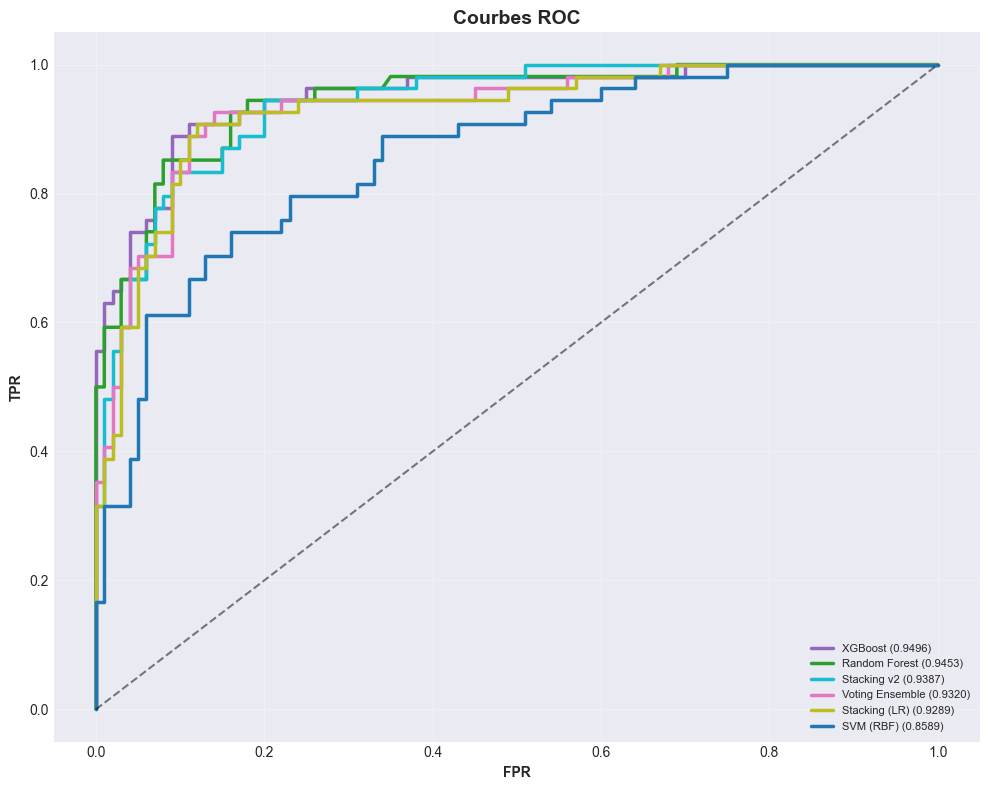

In [18]:
plt.figure(figsize=(10, 8))
colors = plt.cm.tab10(np.linspace(0, 1, len(results)))
for (name, r), c in sorted(zip(results.items(), colors), key=lambda x: x[0][1]['auc'], reverse=True):
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    plt.plot(fpr, tpr, color=c, lw=2.5, label=f"{name} ({r['auc']:.4f})")
plt.plot([0,1], [0,1], 'k--', alpha=0.5)
plt.xlabel('FPR', fontweight='bold'); plt.ylabel('TPR', fontweight='bold')
plt.title('Courbes ROC', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=8); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

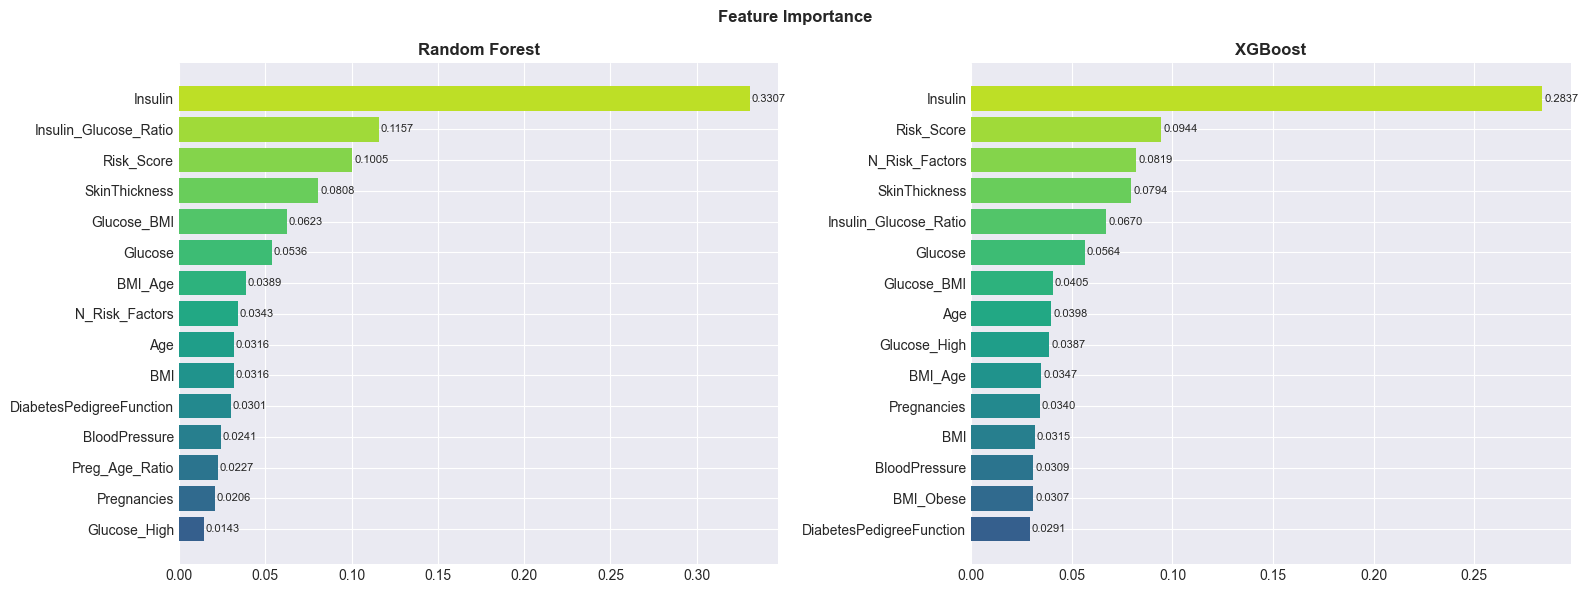

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for idx, (name, model) in enumerate([('Random Forest', rf), (gb_name, gb)]):
    try:
        imp = pd.DataFrame({'Feature': feature_names, 'Imp': model.feature_importances_})
        imp = imp.sort_values('Imp', ascending=True).tail(15)
        axes[idx].barh(imp['Feature'], imp['Imp'], color=plt.cm.viridis(np.linspace(0.3, 0.9, len(imp))))
        axes[idx].set_title(f'{name}', fontweight='bold')
        for i, v in enumerate(imp['Imp']): axes[idx].text(v+0.001, i, f'{v:.4f}', va='center', fontsize=8)
    except: pass
plt.suptitle('Feature Importance', fontweight='bold'); plt.tight_layout(); plt.show()

## 11. Conclusion
### Techniques clés pour 90%+:
- **Borderline-SMOTE** > SMOTE classique
- **PowerTransformer** > StandardScaler pour distributions skewed
- **MLP Neural Network** apporte de la diversité dans l'ensemble
- **Stacking avec passthrough** permet au meta-learner d'accéder aux features originales
- **Optimisation du seuil** cruciale pour les classes déséquilibrées
- **200 trials Optuna** pour XGBoost = exploration très fine de l'espace des hyperparamètres